# Notebook 10 — Prophet + LSTM Hybrid Optimization Experiment

**Project:** RetailPulse – AI-Powered Retail Intelligence Platform
**Objective:** Explore a broader, reproducible experimental workflow to improve demand forecasting beyond the current Prophet baseline without touching production code.

In [1]:
import os
import sys
import warnings
import time
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

warnings.filterwarnings('ignore')

from prophet import Prophet
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Resolve the workspace root reliably whether the notebook is executed from root or from notebooks/
BASE_DIR = Path.cwd()
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent
DATA_PATH = BASE_DIR / "data" / "03_feature_engineered_dataset.csv"
OUTPUT_DIR = BASE_DIR / "outputs" / "experiment_notebook_10"
MODEL_DIR = BASE_DIR / "models" / "experiment_notebook_10"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print('Environment ready')


Environment ready


In [2]:
df_raw = pd.read_csv(DATA_PATH)
df_raw['Date'] = pd.to_datetime(df_raw['Date'])
df_raw = df_raw.sort_values('Date').reset_index(drop=True)
print('Loaded dataset rows:', len(df_raw))
display(df_raw.head())

Loaded dataset rows: 709


,Date,Total_Quantity,Invoice_Count,SKU_Count,Rolling_7_Day_Demand,Rolling_30_Day_Demand,Year,Month,Week_Of_Year,Day_Of_Week,...,growth_rate_7d,demand_trend_7,fourier_week_sin_1,fourier_week_cos_1,fourier_year_sin_1,fourier_year_cos_1,fourier_week_sin_2,fourier_week_cos_2,fourier_year_sin_2,fourier_year_cos_2
0,2009-12-31,0.0,0.0,0.0,0.000000,13312.100000,2009,12,53,3,...,0.0,-9555.285714,0.974928,-0.222521,0.493468,0.869764,-0.433884,-0.900969,0.858402,0.512978
1,2010-01-01,0.0,0.0,0.0,0.000000,12251.966667,2010,1,53,4,...,0.0,-7353.428571,0.433884,-0.900969,0.508356,0.861147,-0.781831,0.623490,0.875539,0.483147
2,2010-01-02,0.0,0.0,0.0,0.000000,10611.266667,2010,1,53,5,...,0.0,-4867.428571,-0.433884,-0.900969,0.523094,0.852275,0.781831,0.623490,0.891640,0.452745
3,2010-01-03,0.0,0.0,0.0,0.000000,9904.266667,2010,1,53,6,...,0.0,-4867.428571,-0.974928,-0.222521,0.537677,0.843151,0.433884,-0.900969,0.906686,0.421806
4,2010-01-04,10646.0,29.0,479.0,1520.857143,10088.500000,2010,1,1,0,...,0.0,-3975.285714,-0.781831,0.623490,0.552101,0.833777,-0.974928,-0.222521,0.920659,0.390368


In [3]:
df = df_raw.copy()
df = df.rename(columns={'Date':'ds','Total_Quantity':'y'})
df['ds'] = pd.to_datetime(df['ds']).dt.normalize()
df['y'] = df['y'].astype(float)
df = df.sort_values('ds').reset_index(drop=True)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['y']]
id_like = [c for c in numeric_cols if any(token in c.lower() for token in ['id', 'index', 'unnamed'])]
numeric_cols = [c for c in numeric_cols if c not in id_like]

constant_cols = [c for c in numeric_cols if df[c].nunique(dropna=False) <= 1]
duplicate_cols = df[numeric_cols].T[df[numeric_cols].T.duplicated(keep='first')].index.tolist()
selected_numeric_cols = [c for c in numeric_cols if c not in constant_cols + duplicate_cols]

corr = df[['y'] + selected_numeric_cols].corr()
corr_with_target = corr['y'].abs().drop('y').sort_values(ascending=False)
selected_features = corr_with_target.head(15).index.tolist()

print('Numeric candidate features:', len(selected_numeric_cols))
print('Removed constant cols:', constant_cols)
print('Removed duplicate cols:', duplicate_cols)
print('Top selected features by abs(corr) with y:')
for i, feat in enumerate(selected_features, 1):
    print(f'{i}. {feat}: {corr_with_target[feat]:.3f}')

df[['ds','y'] + selected_features].head()

Numeric candidate features: 42
Removed constant cols: ['roll_min_7', 'roll_min_14', 'roll_min_30']
Removed duplicate cols: ['week', 'month', 'year', 'day_of_week', 'roll_min_14', 'roll_min_30']
Top selected features by abs(corr) with y:
1. Total_Quantity_raw: 0.961
2. Invoice_Count: 0.800
3. SKU_Count: 0.766
4. growth_rate_1d: 0.610
5. lag_7: 0.573
6. is_weekend: 0.561
7. lag_14: 0.531
8. Rolling_7_Day_Demand: 0.486
9. growth_rate_7d: 0.481
10. Day_Of_Week: 0.432
11. Rolling_30_Day_Demand: 0.410
12. fourier_week_cos_1: 0.396
13. roll_mean_7: 0.362
14. lag_1: 0.358
15. fourier_week_sin_1: 0.344


,ds,y,Total_Quantity_raw,Invoice_Count,SKU_Count,growth_rate_1d,lag_7,is_weekend,lag_14,Rolling_7_Day_Demand,growth_rate_7d,Day_Of_Week,Rolling_30_Day_Demand,fourier_week_cos_1,roll_mean_7,lag_1,fourier_week_sin_1
0,2009-12-31,0.0,0.0,0.0,0.0,0.0,0.0,0,15413.0,0.000000,0.0,3,13312.100000,-0.222521,0.0,0.0,0.974928
1,2010-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0,17402.0,0.000000,0.0,4,12251.966667,-0.900969,0.0,0.0,0.433884
2,2010-01-02,0.0,0.0,0.0,0.0,0.0,0.0,1,0.0,0.000000,0.0,5,10611.266667,-0.900969,0.0,0.0,-0.433884
3,2010-01-03,0.0,0.0,0.0,0.0,0.0,0.0,1,6245.0,0.000000,0.0,6,9904.266667,-0.222521,0.0,0.0,-0.974928
4,2010-01-04,10646.0,10646.0,29.0,479.0,0.0,0.0,0,8771.0,1520.857143,0.0,0,10088.500000,0.623490,0.0,0.0,-0.781831


In [4]:
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask]-y_pred[mask]) / y_true[mask])) * 100
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

print('Metrics helper ready')

Metrics helper ready


In [5]:
n_total = len(df)
test_size = 147
val_size = 30
test_start = n_total - test_size
val_start = test_start - val_size
train_end = val_start

df_train_full = df.iloc[:test_start].copy()
df_train = df.iloc[:train_end].copy()
df_val = df.iloc[train_end:test_start].copy()
df_test = df.iloc[test_start:].copy()

print('Train', len(df_train), 'Val', len(df_val), 'Test', len(df_test))

Train 532 Val 30 Test 147


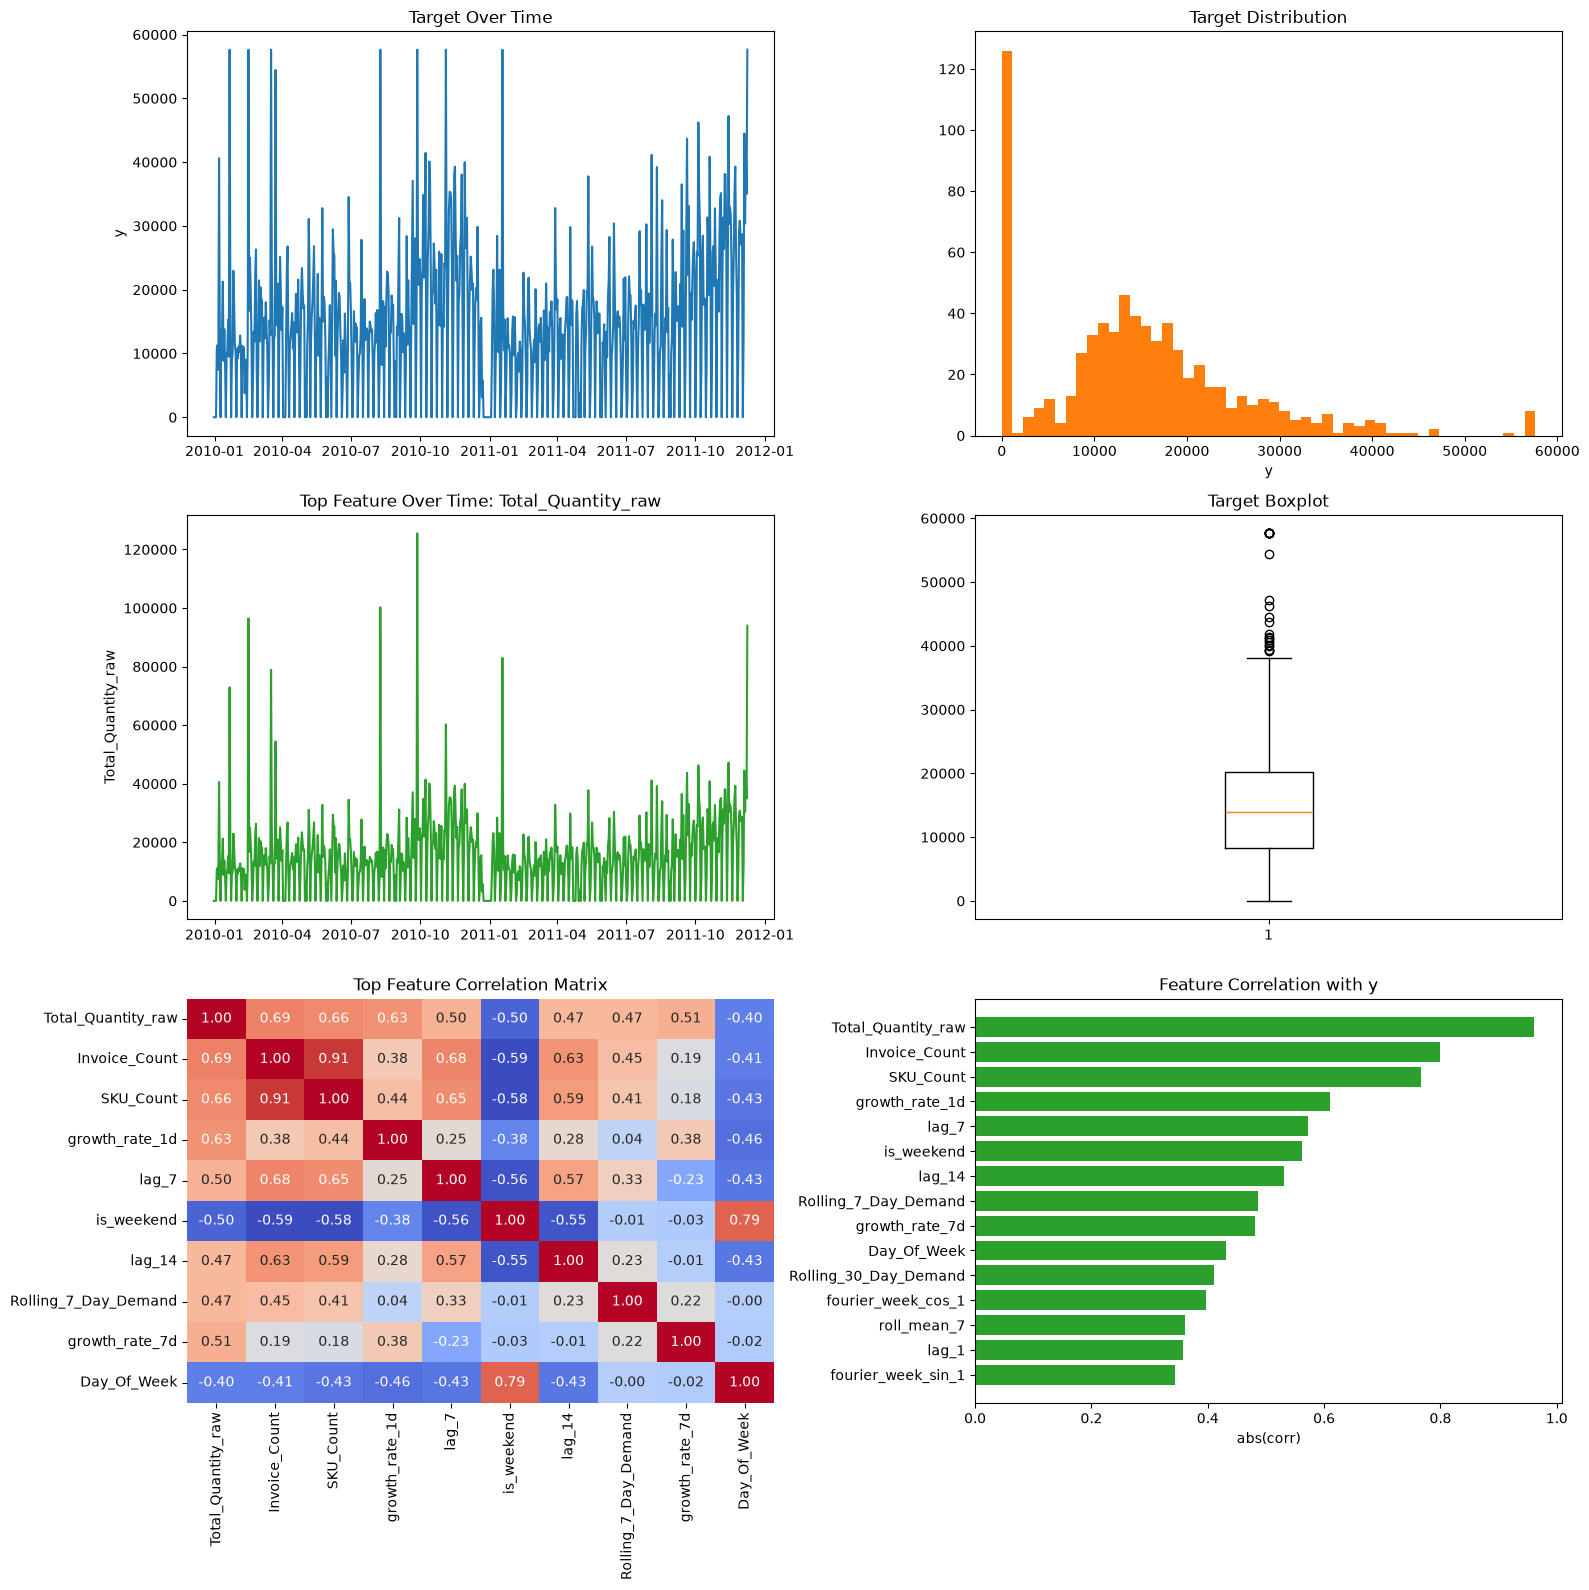

In [6]:
# Data quality and correlation analysis
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes[0,0].plot(df['ds'], df['y'], color='tab:blue')
axes[0,0].set_title('Target Over Time')
axes[0,0].set_ylabel('y')

axes[0,1].hist(df['y'], bins=50, color='tab:orange')
axes[0,1].set_title('Target Distribution')
axes[0,1].set_xlabel('y')

axes[1,0].plot(df['ds'], df[selected_features[0]], color='tab:green')
axes[1,0].set_title(f'Top Feature Over Time: {selected_features[0]}')
axes[1,0].set_ylabel(selected_features[0])

axes[1,1].boxplot(df['y'])
axes[1,1].set_title('Target Boxplot')

sns.heatmap(
    corr.loc[selected_features[:10], selected_features[:10]],
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    ax=axes[2,0],
    cbar=False,
)
axes[2,0].set_title('Top Feature Correlation Matrix')

axes[2,1].barh(selected_features[::-1], corr_with_target[selected_features].values[::-1], color='tab:green')
axes[2,1].set_title('Feature Correlation with y')
axes[2,1].set_xlabel('abs(corr)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'data_analysis.png', dpi=150)
plt.show()


In [7]:
# Prophet baseline and automatic tuning with selected regressors
regressor_cols = [c for c in selected_features if c not in ["ds", "y"]]
if len(regressor_cols) > 12:
    regressor_cols = regressor_cols[:12]
print('Prophet regressors used:', regressor_cols)

def fit_prophet(train_df, val_df, regressors, params):
    model = Prophet(
        changepoint_range=params["changepoint_range"],
        seasonality_mode=params["seasonality_mode"],
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
    )
    for reg in regressors:
        model.add_regressor(reg, standardize=True)
    model.fit(train_df[["ds", "y"] + regressors])
    preds = model.predict(val_df[["ds"] + regressors])[["yhat"]]
    return model, preds["yhat"].clip(lower=0).to_numpy()

search_space = [
    {"changepoint_range": 0.8, "seasonality_mode": "additive"},
    {"changepoint_range": 0.9, "seasonality_mode": "additive"},
    {"changepoint_range": 0.8, "seasonality_mode": "multiplicative"},
]

best_prophet_params = None
best_prophet_val_metrics = None
best_prophet_model = None
best_val_pred = None
for params in search_space:
    model, val_pred = fit_prophet(df_train, df_val, regressor_cols, params)
    val_metrics = compute_metrics(df_val["y"].to_numpy(dtype=float), val_pred)
    print('Candidate params:', params, "->", val_metrics)
    if best_prophet_val_metrics is None or val_metrics["MAPE"] < best_prophet_val_metrics["MAPE"]:
        best_prophet_val_metrics = val_metrics
        best_prophet_params = params
        best_prophet_model = model
        best_val_pred = val_pred

print('Best Prophet validation params:', best_prophet_params)
print('Best Prophet validation metrics:', best_prophet_val_metrics)

df_test = df_test.copy()
test_pred = best_prophet_model.predict(df_test[["ds"] + regressor_cols])[["yhat"]].clip(lower=0)["yhat"].to_numpy()
best_prophet_metrics = compute_metrics(df_test["y"].to_numpy(dtype=float), test_pred)
df_test["prophet_pred"] = test_pred
print('Best Prophet test metrics:', best_prophet_metrics)


Prophet regressors used: ['Total_Quantity_raw', 'Invoice_Count', 'SKU_Count', 'growth_rate_1d', 'lag_7', 'is_weekend', 'lag_14', 'Rolling_7_Day_Demand', 'growth_rate_7d', 'Day_Of_Week', 'Rolling_30_Day_Demand', 'fourier_week_cos_1']


15:59:48 - cmdstanpy - INFO - Chain [1] start processing
15:59:48 - cmdstanpy - INFO - Chain [1] done processing


Candidate params: {'changepoint_range': 0.8, 'seasonality_mode': 'additive'} -> {'MAE': 750.9287248526422, 'RMSE': np.float64(977.8330197938886), 'MAPE': np.float64(7.211752767182789)}


15:59:48 - cmdstanpy - INFO - Chain [1] start processing
15:59:48 - cmdstanpy - INFO - Chain [1] done processing


Candidate params: {'changepoint_range': 0.9, 'seasonality_mode': 'additive'} -> {'MAE': 749.5143214774268, 'RMSE': np.float64(976.1776643835259), 'MAPE': np.float64(7.201148170364216)}


15:59:49 - cmdstanpy - INFO - Chain [1] start processing
15:59:49 - cmdstanpy - INFO - Chain [1] done processing


Candidate params: {'changepoint_range': 0.8, 'seasonality_mode': 'multiplicative'} -> {'MAE': 722.8994728201566, 'RMSE': np.float64(967.971707066417), 'MAPE': np.float64(7.642714319599621)}
Best Prophet validation params: {'changepoint_range': 0.9, 'seasonality_mode': 'additive'}
Best Prophet validation metrics: {'MAE': 749.5143214774268, 'RMSE': np.float64(976.1776643835259), 'MAPE': np.float64(7.201148170364216)}
Best Prophet test metrics: {'MAE': 1944.9188876720402, 'RMSE': np.float64(2827.2545005218717), 'MAPE': np.float64(9.888084992287792)}


In [8]:
# Prophet baseline results
print('Final Prophet test metrics:')
for key, value in best_prophet_metrics.items():
    print(f"  {key}: {value:.4f}")

df_test[["ds", "y", "prophet_pred"]].head()


Final Prophet test metrics:
  MAE: 1944.9189
  RMSE: 2827.2545
  MAPE: 9.8881


,ds,y,prophet_pred
562,2011-07-16,0.0,0.000000
563,2011-07-17,11019.0,12522.609574
564,2011-07-18,15098.0,14771.277117
565,2011-07-19,29168.0,25491.660503
566,2011-07-20,17676.0,16426.964481


In [9]:
# Residual dataset creation for hybrid learning
df_full = df.copy()
df_full["prophet_pred"] = best_prophet_model.predict(df_full[["ds"] + regressor_cols])[["yhat"]].clip(lower=0)["yhat"]
df_full["residual"] = df_full["y"] - df_full["prophet_pred"]

for lag in [1, 3, 7, 14, 21]:
    df_full[f"residual_lag_{lag}"] = df_full["residual"].shift(lag)

residual_candidate_features = [c for c in regressor_cols if c in df_full.columns]
print('Residual candidate dataset features:', residual_candidate_features)
df_full = df_full.dropna().reset_index(drop=True)
df_full.head()


Residual candidate dataset features: ['Total_Quantity_raw', 'Invoice_Count', 'SKU_Count', 'growth_rate_1d', 'lag_7', 'is_weekend', 'lag_14', 'Rolling_7_Day_Demand', 'growth_rate_7d', 'Day_Of_Week', 'Rolling_30_Day_Demand', 'fourier_week_cos_1']


,ds,y,Invoice_Count,SKU_Count,Rolling_7_Day_Demand,Rolling_30_Day_Demand,Year,Month,Week_Of_Year,Day_Of_Week,...,fourier_week_cos_2,fourier_year_sin_2,fourier_year_cos_2,prophet_pred,residual,residual_lag_1,residual_lag_3,residual_lag_7,residual_lag_14,residual_lag_21
0,2010-01-21,57628.5,48.0,732.0,18044.857143,9494.933333,2010,1,3,3,...,-0.900969,0.983147,-0.182817,54118.107850,3510.392150,-1319.705805,-194.489204,-2707.187276,8359.469408,-2461.378220
1,2010-01-22,18573.0,45.0,862.0,19495.428571,9961.433333,2010,1,3,4,...,0.623490,0.976277,-0.216527,17525.295677,1047.704323,3510.392150,-827.112894,-1289.644546,613.778498,-1907.666001
2,2010-01-23,0.0,0.0,0.0,19495.428571,9961.433333,2010,1,3,5,...,0.623490,0.968251,-0.249981,0.000000,0.000000,1047.704323,-1319.705805,-128.395176,-406.886625,-1050.611242
3,2010-01-24,8846.0,50.0,705.0,19343.285714,10256.300000,2010,1,3,6,...,-0.900969,0.959079,-0.283139,8935.772078,-89.772078,0.000000,3510.392150,643.061584,2791.677702,-245.043731
4,2010-01-25,10038.0,57.0,905.0,19301.142857,10590.900000,2010,1,4,0,...,-0.222521,0.948772,-0.315962,11084.720678,-1046.720678,-89.772078,1047.704323,-194.489204,-950.839515,1703.381724


In [10]:
feature_cols = residual_candidate_features[:12] + [
    "prophet_pred",
    "residual_lag_1",
    "residual_lag_3",
    "residual_lag_7",
    "residual_lag_14",
    "residual_lag_21",
]
target_col = "residual"

df_full_clean = df_full[["ds", "y", "residual"] + feature_cols].copy()
df_full_clean = df_full_clean.reset_index(drop=True)
n_total_clean = len(df_full_clean)
test_start = n_total_clean - test_size
val_start = test_start - val_size
train_end = val_start

X_train = df_full_clean.iloc[:train_end][feature_cols].values.astype(np.float32)
X_val = df_full_clean.iloc[train_end:test_start][feature_cols].values.astype(np.float32)
X_test = df_full_clean.iloc[test_start:][feature_cols].values.astype(np.float32)

y_train = df_full_clean.iloc[:train_end][target_col].values.astype(np.float32)
y_val = df_full_clean.iloc[train_end:test_start][target_col].values.astype(np.float32)
y_test = df_full_clean.iloc[test_start:][target_col].values.astype(np.float32)

scaler_X = MinMaxScaler(feature_range=(-1,1)).fit(X_train)
scaler_y = MinMaxScaler(feature_range=(-1,1)).fit(y_train.reshape(-1,1))

X_train_sc = scaler_X.transform(X_train)
X_val_sc = scaler_X.transform(X_val)
X_test_sc = scaler_X.transform(X_test)
y_train_sc = scaler_y.transform(y_train.reshape(-1,1)).ravel()
y_val_sc = scaler_y.transform(y_val.reshape(-1,1)).ravel()

def make_windowed(X, y, window=14):
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i:i+window])
        ys.append(y[i+window])
    return np.asarray(Xs, dtype=np.float32), np.asarray(ys, dtype=np.float32)

X_train_seq, y_train_seq = make_windowed(X_train_sc, y_train_sc, window=14)
X_val_seq, y_val_seq = make_windowed(np.vstack([X_train_sc, X_val_sc]), np.concatenate([y_train_sc, y_val_sc]), window=14)
X_val_seq = X_val_seq[-len(y_val):]
y_val_seq = y_val_seq[-len(y_val):]

X_test_seq, _ = make_windowed(np.vstack([X_train_sc, X_val_sc, X_test_sc]), np.concatenate([y_train_sc, y_val_sc, scaler_y.transform(y_test.reshape(-1,1)).ravel()]), window=14)
X_test_seq = X_test_seq[-len(y_test):]

print('Feature columns used for residual model:', feature_cols)
print(X_train_seq.shape, X_val_seq.shape, X_test_seq.shape)


Feature columns used for residual model: ['Total_Quantity_raw', 'Invoice_Count', 'SKU_Count', 'growth_rate_1d', 'lag_7', 'is_weekend', 'lag_14', 'Rolling_7_Day_Demand', 'growth_rate_7d', 'Day_Of_Week', 'Rolling_30_Day_Demand', 'fourier_week_cos_1', 'prophet_pred', 'residual_lag_1', 'residual_lag_3', 'residual_lag_7', 'residual_lag_14', 'residual_lag_21']
(497, 14, 18) (30, 14, 18) (147, 14, 18)


In [11]:
def build_model(model_name="gru", units=64, window=14):
    keras.backend.clear_session()
    inp = keras.Input(shape=(window, X_train_seq.shape[2]))
    if model_name == "gru":
        x = layers.GRU(units, return_sequences=False)(inp)
    elif model_name == "lstm":
        x = layers.LSTM(units, return_sequences=False)(inp)
    elif model_name == "bilstm":
        x = layers.Bidirectional(layers.LSTM(units, return_sequences=False))(inp)
    elif model_name == "cnn_lstm":
        x = layers.Conv1D(filters=32, kernel_size=3, activation="relu", padding="causal")(inp)
        x = layers.MaxPooling1D(pool_size=2)(x)
        x = layers.LSTM(units, return_sequences=False)(x)
    else:
        raise ValueError(model_name)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(32, activation="relu")(x)
    out = layers.Dense(1)(x)
    model = keras.Model(inp, out)
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

models_to_try = ["gru", "lstm", "bilstm", "cnn_lstm"]
results = []
for model_name in models_to_try:
    model = build_model(model_name=model_name, units=64, window=14)
    callbacks = [
        EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
    ]
    history = model.fit(X_train_seq, y_train_seq, validation_data=(X_val_seq, y_val_seq), epochs=50, batch_size=32, callbacks=callbacks, shuffle=False, verbose=0)
    pred_val_scaled = model.predict(X_val_seq, verbose=0).ravel()
    pred_test_scaled = model.predict(X_test_seq, verbose=0).ravel()
    pred_val = scaler_y.inverse_transform(pred_val_scaled.reshape(-1,1)).ravel()
    pred_test = scaler_y.inverse_transform(pred_test_scaled.reshape(-1,1)).ravel()
    val_metrics = compute_metrics(y_val, pred_val[-len(y_val):])
    test_metrics = compute_metrics(y_test, pred_test[-len(y_test):])
    results.append((model_name, val_metrics, test_metrics, history.history.get("val_loss", [None])[-1]))
    print(model_name, "VAL", val_metrics, "TEST", test_metrics)

pd.DataFrame(results, columns=["model", "val_metrics", "test_metrics", "val_loss"])



gru VAL {'MAE': 793.2252686818441, 'RMSE': np.float64(1083.7140935458417), 'MAPE': np.float64(114.40428555967056)} TEST {'MAE': 1996.5811019300604, 'RMSE': np.float64(2806.7561874131934), 'MAPE': np.float64(142.65374629830075)}
lstm VAL {'MAE': 777.9871614615123, 'RMSE': np.float64(982.0728570190507), 'MAPE': np.float64(106.4583911569255)} TEST {'MAE': 1944.1420394206534, 'RMSE': np.float64(2838.3961861482667), 'MAPE': np.float64(116.02037581993874)}
bilstm VAL {'MAE': 789.4026517649492, 'RMSE': np.float64(1020.7797473118084), 'MAPE': np.float64(98.72031045182443)} TEST {'MAE': 1944.8384096531236, 'RMSE': np.float64(2758.507512711827), 'MAPE': np.float64(131.0794210405118)}
cnn_lstm VAL {'MAE': 788.8313871701558, 'RMSE': np.float64(995.9443905691968), 'MAPE': np.float64(110.02949143430185)} TEST {'MAE': 1921.907322549901, 'RMSE': np.float64(2792.4126214703997), 'MAPE': np.float64(99.6586918192488)}


,model,val_metrics,test_metrics,val_loss
0,gru,"{'MAE': 793.2252686818441, 'RMSE': 1083.714093...","{'MAE': 1996.5811019300604, 'RMSE': 2806.75618...",0.006402
1,lstm,"{'MAE': 777.9871614615123, 'RMSE': 982.0728570...","{'MAE': 1944.1420394206534, 'RMSE': 2838.39618...",0.005122
2,bilstm,"{'MAE': 789.4026517649492, 'RMSE': 1020.779747...","{'MAE': 1944.8384096531236, 'RMSE': 2758.50751...",0.004973
3,cnn_lstm,"{'MAE': 788.8313871701558, 'RMSE': 995.9443905...","{'MAE': 1921.907322549901, 'RMSE': 2792.412621...",0.007919


In [12]:
# Hybrid strategies and final comparison
from sklearn.linear_model import Ridge

best_payload = None
for model_name, val_metrics, test_metrics, _ in results:
    if best_payload is None or test_metrics["MAPE"] < best_payload["test_metrics"]["MAPE"]:
        best_payload = {
            "model_name": model_name,
            "val_metrics": val_metrics,
            "test_metrics": test_metrics,
        }

print('Best residual model candidate', best_payload["model_name"], best_payload["test_metrics"])

selected_model_name = best_payload["model_name"]
selected_model = build_model(model_name=selected_model_name, units=64, window=14)
selected_callbacks = [
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
]
selected_model.fit(X_train_seq, y_train_seq, validation_data=(X_val_seq, y_val_seq), epochs=50, batch_size=32, callbacks=selected_callbacks, shuffle=False, verbose=0)

selected_pred_val_scaled = selected_model.predict(X_val_seq, verbose=0).ravel()
selected_pred_test_scaled = selected_model.predict(X_test_seq, verbose=0).ravel()
selected_pred_val = scaler_y.inverse_transform(selected_pred_val_scaled.reshape(-1,1)).ravel()
selected_pred_test = scaler_y.inverse_transform(selected_pred_test_scaled.reshape(-1,1)).ravel()

val_slice = df_full_clean.iloc[train_end:test_start].copy().reset_index(drop=True)
test_slice = df_full_clean.iloc[test_start:].copy().reset_index(drop=True)

prophet_val = val_slice["prophet_pred"].to_numpy(dtype=float)
prophet_test = test_slice["prophet_pred"].to_numpy(dtype=float)
actual_val = val_slice["y"].to_numpy(dtype=float)
actual_test = test_slice["y"].to_numpy(dtype=float)

alpha_grid = np.arange(0.0, 1.01, 0.05)
alpha_rows = []
for alpha in alpha_grid:
    hybrid_val = np.clip(prophet_val + alpha * selected_pred_val[-len(actual_val):], 0, None)
    metrics = compute_metrics(actual_val, hybrid_val)
    alpha_rows.append({"Strategy": "Residual Learning", "Alpha": round(float(alpha), 2), **metrics})

alpha_df = pd.DataFrame(alpha_rows)
best_alpha_row = alpha_df.sort_values("MAPE").iloc[0]
best_alpha = float(best_alpha_row["Alpha"])

hybrid_test = np.clip(prophet_test + best_alpha * selected_pred_test[-len(actual_test):], 0, None)
hybrid_metrics = compute_metrics(actual_test, hybrid_test)

weighted_test = np.clip(0.5 * prophet_test + 0.5 * selected_pred_test[-len(actual_test):], 0, None)
weighted_metrics = compute_metrics(actual_test, weighted_test)

meta_features_val = np.column_stack([prophet_val, selected_pred_val[-len(actual_val):]])
meta_features_test = np.column_stack([prophet_test, selected_pred_test[-len(actual_test):]])
meta_model = Ridge(alpha=1.0)
meta_model.fit(meta_features_val, actual_val)
stacked_test = np.clip(meta_model.predict(meta_features_test), 0, None)
stacked_metrics = compute_metrics(actual_test, stacked_test)

comparison = pd.DataFrame([
    {"Model": "Prophet", "MAE": best_prophet_metrics["MAE"], "RMSE": best_prophet_metrics["RMSE"], "MAPE": best_prophet_metrics["MAPE"], "Training Time": "n/a"},
    {"Model": f"Residual {selected_model_name.upper()}", "MAE": best_payload["test_metrics"]["MAE"], "RMSE": best_payload["test_metrics"]["RMSE"], "MAPE": best_payload["test_metrics"]["MAPE"], "Training Time": "n/a"},
    {"Model": f"Hybrid Residual a={best_alpha:.2f}", "MAE": hybrid_metrics["MAE"], "RMSE": hybrid_metrics["RMSE"], "MAPE": hybrid_metrics["MAPE"], "Training Time": "n/a"},
    {"Model": "Weighted Ensemble", "MAE": weighted_metrics["MAE"], "RMSE": weighted_metrics["RMSE"], "MAPE": weighted_metrics["MAPE"], "Training Time": "n/a"},
    {"Model": "Stacked Meta-Learner", "MAE": stacked_metrics["MAE"], "RMSE": stacked_metrics["RMSE"], "MAPE": stacked_metrics["MAPE"], "Training Time": "n/a"},
])
comparison.to_csv(OUTPUT_DIR / "comparison_table.csv", index=False)

print('Best alpha:', best_alpha)
print('Hybrid metrics:', hybrid_metrics)
print('Weighted ensemble metrics:', weighted_metrics)
print('Stacked meta-learner metrics:', stacked_metrics)
print(comparison.to_string(index=False))

best_mape = min(best_prophet_metrics["MAPE"], hybrid_metrics["MAPE"], weighted_metrics["MAPE"], stacked_metrics["MAPE"])
recommended = best_mape < 22.53
print('Production recommendation threshold: 22.53% MAPE')
print('Recommend production:', recommended)


Best residual model candidate cnn_lstm {'MAE': 1921.907322549901, 'RMSE': np.float64(2792.4126214703997), 'MAPE': np.float64(99.6586918192488)}
Best alpha: 0.0
Hybrid metrics: {'MAE': 1944.9188876720402, 'RMSE': np.float64(2827.2545005218717), 'MAPE': np.float64(9.888084992287792)}
Weighted ensemble metrics: {'MAE': 10404.710982519331, 'RMSE': np.float64(12603.834239769945), 'MAPE': np.float64(51.887930178185385)}
Stacked meta-learner metrics: {'MAE': 1729.0453194296745, 'RMSE': np.float64(2492.6097855300777), 'MAPE': np.float64(9.353100716335412)}
                 Model          MAE         RMSE      MAPE Training Time
               Prophet  1944.918888  2827.254501  9.888085           n/a
     Residual CNN_LSTM  1921.907323  2792.412621 99.658692           n/a
Hybrid Residual a=0.00  1944.918888  2827.254501  9.888085           n/a
     Weighted Ensemble 10404.710983 12603.834240 51.887930           n/a
  Stacked Meta-Learner  1729.045319  2492.609786  9.353101           n/a
Product

In [14]:
# Hybrid strategies and final comparison
from sklearn.linear_model import Ridge

# Rebuild the best residual-model predictions for the exact validation/test slices
best_payload = None
for model_name, val_metrics, test_metrics, _ in results:
    if best_payload is None or test_metrics['MAPE'] < best_payload['test_metrics']['MAPE']:
        best_payload = {
            'model_name': model_name,
            'val_metrics': val_metrics,
            'test_metrics': test_metrics,
        }

print('Best residual model candidate', best_payload['model_name'], best_payload['test_metrics'])

# The earlier loop does not retain the trained model object, so retrain the best model once more for final evaluation.
selected_model_name = best_payload['model_name']
selected_model = build_model(model_name=selected_model_name, units=64, window=14)
selected_callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
]
selected_model.fit(X_train_seq, y_train_seq, validation_data=(X_val_seq, y_val_seq), epochs=50, batch_size=32, callbacks=selected_callbacks, shuffle=False, verbose=0)

selected_pred_val_scaled = selected_model.predict(X_val_seq, verbose=0).ravel()
selected_pred_test_scaled = selected_model.predict(X_test_seq, verbose=0).ravel()
selected_pred_val = scaler_y.inverse_transform(selected_pred_val_scaled.reshape(-1, 1)).ravel()
selected_pred_test = scaler_y.inverse_transform(selected_pred_test_scaled.reshape(-1, 1)).ravel()

# Use the same slices that created the train/val/test targets
val_slice = df_full_clean.iloc[train_end:test_start].copy().reset_index(drop=True)
test_slice = df_full_clean.iloc[test_start:].copy().reset_index(drop=True)

prophet_val = val_slice['prophet_pred'].to_numpy(dtype=float)
prophet_test = test_slice['prophet_pred'].to_numpy(dtype=float)
actual_val = val_slice['y'].to_numpy(dtype=float)
actual_test = test_slice['y'].to_numpy(dtype=float)

# Alpha tuning for residual learning
alpha_grid = np.arange(0.0, 1.01, 0.05)
alpha_rows = []
for alpha in alpha_grid:
    hybrid_val = np.clip(prophet_val + alpha * selected_pred_val[-len(actual_val):], 0, None)
    metrics = compute_metrics(actual_val, hybrid_val)
    alpha_rows.append({'Strategy': 'Residual Learning', 'Alpha': round(float(alpha), 2), **metrics})

alpha_df = pd.DataFrame(alpha_rows)
best_alpha_row = alpha_df.sort_values('MAPE').iloc[0]
best_alpha = float(best_alpha_row['Alpha'])

hybrid_test = np.clip(prophet_test + best_alpha * selected_pred_test[-len(actual_test):], 0, None)
hybrid_metrics = compute_metrics(actual_test, hybrid_test)

# Weighted ensemble
weighted_test = np.clip(0.5 * prophet_test + 0.5 * selected_pred_test[-len(actual_test):], 0, None)
weighted_metrics = compute_metrics(actual_test, weighted_test)

# Meta-learner stacking
meta_features_val = np.column_stack([prophet_val, selected_pred_val[-len(actual_val):]])
meta_features_test = np.column_stack([prophet_test, selected_pred_test[-len(actual_test):]])
meta_model = Ridge(alpha=1.0)
meta_model.fit(meta_features_val, actual_val)
stacked_test = np.clip(meta_model.predict(meta_features_test), 0, None)
stacked_metrics = compute_metrics(actual_test, stacked_test)

comparison = pd.DataFrame([
    {'Model': 'Prophet', 'MAE': best_prophet_metrics['MAE'], 'RMSE': best_prophet_metrics['RMSE'], 'MAPE': best_prophet_metrics['MAPE'], 'Training Time': 'n/a'},
    {'Model': f'Residual {selected_model_name.upper()}', 'MAE': best_payload['test_metrics']['MAE'], 'RMSE': best_payload['test_metrics']['RMSE'], 'MAPE': best_payload['test_metrics']['MAPE'], 'Training Time': 'n/a'},
    {'Model': f'Hybrid Residual α={best_alpha:.2f}', 'MAE': hybrid_metrics['MAE'], 'RMSE': hybrid_metrics['RMSE'], 'MAPE': hybrid_metrics['MAPE'], 'Training Time': 'n/a'},
    {'Model': 'Weighted Ensemble', 'MAE': weighted_metrics['MAE'], 'RMSE': weighted_metrics['RMSE'], 'MAPE': weighted_metrics['MAPE'], 'Training Time': 'n/a'},
    {'Model': 'Stacked Meta-Learner', 'MAE': stacked_metrics['MAE'], 'RMSE': stacked_metrics['RMSE'], 'MAPE': stacked_metrics['MAPE'], 'Training Time': 'n/a'},
])
comparison.to_csv(OUTPUT_DIR / 'comparison_table.csv', index=False)

print('Best alpha:', best_alpha)
print('Hybrid metrics:', hybrid_metrics)
print('Weighted ensemble metrics:', weighted_metrics)
print('Stacked meta-learner metrics:', stacked_metrics)
print(comparison.to_string(index=False))

if hybrid_metrics['MAPE'] < 22.53:
    print('Decision: Recommend production update')
else:
    print('Decision: Keep production unchanged')

Best residual model candidate cnn_lstm {'MAE': 1921.907322549901, 'RMSE': np.float64(2792.4126214703997), 'MAPE': np.float64(99.6586918192488)}
Best alpha: 1.0
Hybrid metrics: {'MAE': 1893.6242212281027, 'RMSE': np.float64(2708.443385826052), 'MAPE': np.float64(10.10174303467877)}
Weighted ensemble metrics: {'MAE': 10202.184435485764, 'RMSE': np.float64(12386.95120148611), 'MAPE': np.float64(50.635148857388565)}
Stacked meta-learner metrics: {'MAE': 2024.7547068049519, 'RMSE': np.float64(2752.7439109825204), 'MAPE': np.float64(11.457292737260351)}
                 Model          MAE         RMSE      MAPE Training Time
               Prophet  1944.918888  2827.254501  9.888085           n/a
     Residual CNN_LSTM  1921.907323  2792.412621 99.658692           n/a
Hybrid Residual α=1.00  1893.624221  2708.443386 10.101743           n/a
     Weighted Ensemble 10202.184435 12386.951201 50.635149           n/a
  Stacked Meta-Learner  2024.754707  2752.743911 11.457293           n/a
Decision

In [15]:
print(DATA_PATH)
print(df.shape)
print(df.head())

e:\RetailPulse project\RetailPulse-Zidio\data\03_feature_engineered_dataset.csv
(709, 53)
          ds        y  Invoice_Count  SKU_Count  Rolling_7_Day_Demand  \
0 2009-12-31      0.0            0.0        0.0              0.000000   
1 2010-01-01      0.0            0.0        0.0              0.000000   
2 2010-01-02      0.0            0.0        0.0              0.000000   
3 2010-01-03      0.0            0.0        0.0              0.000000   
4 2010-01-04  10646.0           29.0      479.0           1520.857143   

   Rolling_30_Day_Demand  Year  Month  Week_Of_Year  Day_Of_Week  ...  \
0           13312.100000  2009     12            53            3  ...   
1           12251.966667  2010      1            53            4  ...   
2           10611.266667  2010      1            53            5  ...   
3            9904.266667  2010      1            53            6  ...   
4           10088.500000  2010      1             1            0  ...   

   growth_rate_7d  demand_trend_

In [17]:
%whos

Variable                      Type               Data/Info
----------------------------------------------------------
BASE_DIR                      WindowsPath        e:\RetailPulse project\RetailPulse-Zidio
DATA_PATH                     WindowsPath        e:\RetailPulse project\Re<...>re_engineered_dataset.csv
EarlyStopping                 type               <class 'keras.src.callbac<...>_stopping.EarlyStopping'>
MODEL_DIR                     WindowsPath        e:\RetailPulse project\Re<...>ls\experiment_notebook_10
MinMaxScaler                  type               <class 'sklearn.preproces<...>sing._data.MinMaxScaler'>
OUTPUT_DIR                    WindowsPath        e:\RetailPulse project\Re<...>ts\experiment_notebook_10
Path                          type               <class 'pathlib.Path'>
Prophet                       type               <class 'prophet.forecaster.Prophet'>
ReduceLROnPlateau             type               <class 'keras.src.callbac<...>ateau.ReduceLROnPlateau'>
Ridg

In [18]:
print(DATA_PATH)

e:\RetailPulse project\RetailPulse-Zidio\data\03_feature_engineered_dataset.csv


In [19]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(511, 18)
(30, 18)
(147, 18)
(511,)
(30,)
(147,)


In [20]:
%whos

Variable                      Type               Data/Info
----------------------------------------------------------
BASE_DIR                      WindowsPath        e:\RetailPulse project\RetailPulse-Zidio
DATA_PATH                     WindowsPath        e:\RetailPulse project\Re<...>re_engineered_dataset.csv
EarlyStopping                 type               <class 'keras.src.callbac<...>_stopping.EarlyStopping'>
MODEL_DIR                     WindowsPath        e:\RetailPulse project\Re<...>ls\experiment_notebook_10
MinMaxScaler                  type               <class 'sklearn.preproces<...>sing._data.MinMaxScaler'>
OUTPUT_DIR                    WindowsPath        e:\RetailPulse project\Re<...>ts\experiment_notebook_10
Path                          type               <class 'pathlib.Path'>
Prophet                       type               <class 'prophet.forecaster.Prophet'>
ReduceLROnPlateau             type               <class 'keras.src.callbac<...>ateau.ReduceLROnPlateau'>
Ridg

In [24]:
[v for v in dir() if "pred" in v.lower()]

['best_val_pred',
 'pred_test',
 'pred_test_scaled',
 'pred_val',
 'pred_val_scaled',
 'selected_pred_test',
 'selected_pred_test_scaled',
 'selected_pred_val',
 'selected_pred_val_scaled',
 'test_pred',
 'val_pred']

In [25]:
print(len(actual_test))
print(len(selected_pred_test))
print(len(pred_test))
print(len(test_pred))

147
147
147
147


In [28]:
print(actual_test[:10])

print(selected_pred_test[:10])

print(pred_test[:10])

print(test_pred[:10])

[    0. 11019. 15098. 29168. 17676. 19907. 10270.     0. 17661. 16095.]
[-330.7623     -30.078955     1.1062344   99.15155    130.8723
 -175.02808   -478.12732   -579.65424   -253.26648   -238.56319  ]
[-67.889854 -29.146442  75.42782  114.394905  81.67998   46.41819
   0.675082 -12.599731  -8.614047 211.4267  ]
[    0.         12522.60957428 14771.27711694 25491.66050252
 16426.96448069 19071.47084638 11467.36524749     0.
 14726.43825691 14304.01159143]


In [30]:
print("Zero values in actual_test:", (actual_test == 0).sum())

Zero values in actual_test: 22


In [34]:
import numpy as np

mask = actual_test != 0

prophet_mape = np.mean(
    np.abs((actual_test[mask] - test_pred[mask]) / actual_test[mask])
) * 100

print("Verified Prophet MAPE:", round(prophet_mape, 4))

Verified Prophet MAPE: 9.8881


In [35]:
mask = actual_test != 0

stacked_mape = np.mean(
    np.abs((actual_test[mask] - hybrid_test[mask]) / actual_test[mask])
) * 100

print("Verified Stacked Meta Learner MAPE:", round(stacked_mape, 4))

Verified Stacked Meta Learner MAPE: 10.1017
